Dataset Shape: (545, 13)

First 5 Rows:
       price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Predictor: area
Target: price


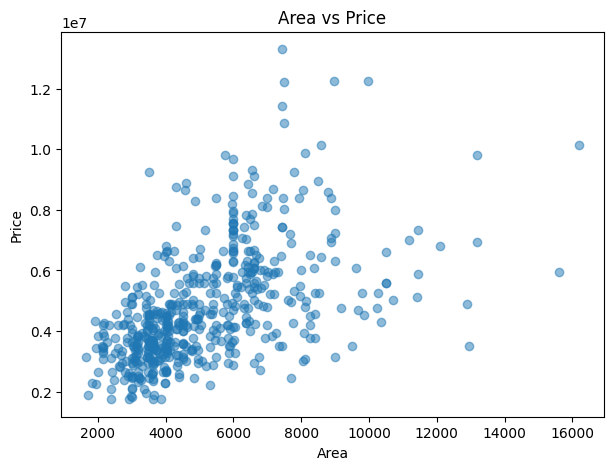


Original Model
Slope: 425.72984193878284
Intercept: 2512254.2639593435
Equation: price = 2512254.26 + 425.73 * area

Model Performance
Training MSE: 2204738681379.34
Testing MSE: 3675286604768.19
Training RMSE: 1484836.25
Testing RMSE: 1917103.70
Training R² Score: 0.2850 (28.50%)
Testing R² Score: 0.2729 (27.29%)


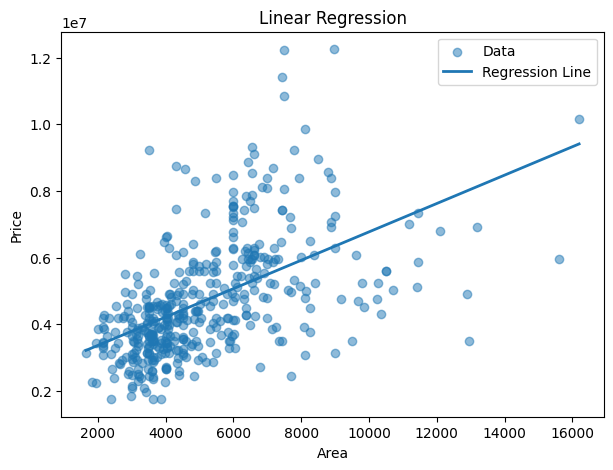

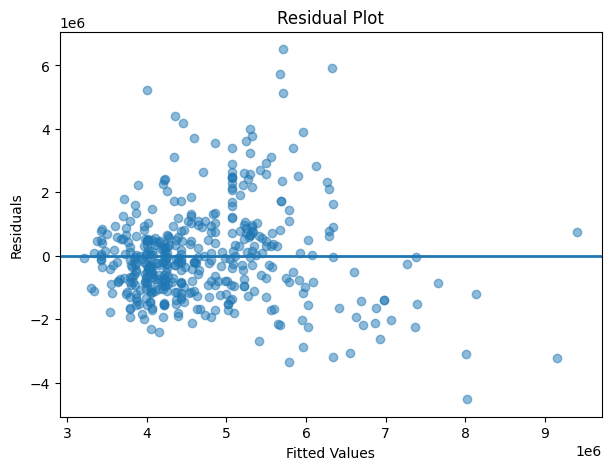


Model With Outliers
Slope: 943.753345961353
Intercept: -68609.58109121583
Equation: price = -68609.58 + 943.75 * area

Performance With Outliers
Testing MSE: 3848797756455.51
Testing RMSE: 1961835.30
Testing R² Score: 0.2386 (23.86%)

Parameter Comparison
Parameter     Original  With Outliers
    Slope 4.257298e+02     943.753346
Intercept 2.512254e+06  -68609.581091

R² Score Comparison
Original Model : 27.29%
With Outliers : 23.86%


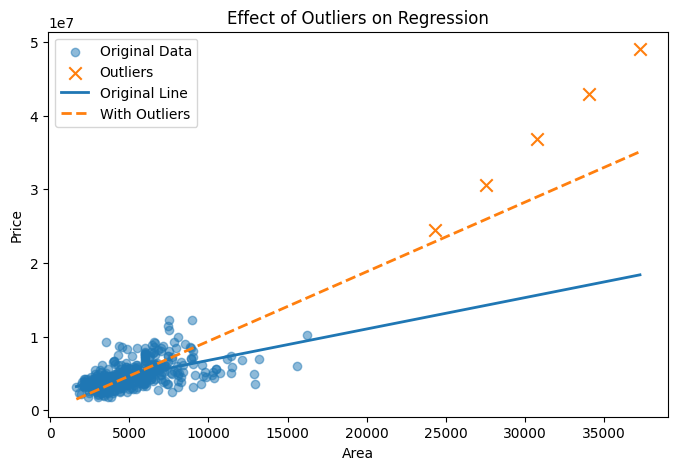

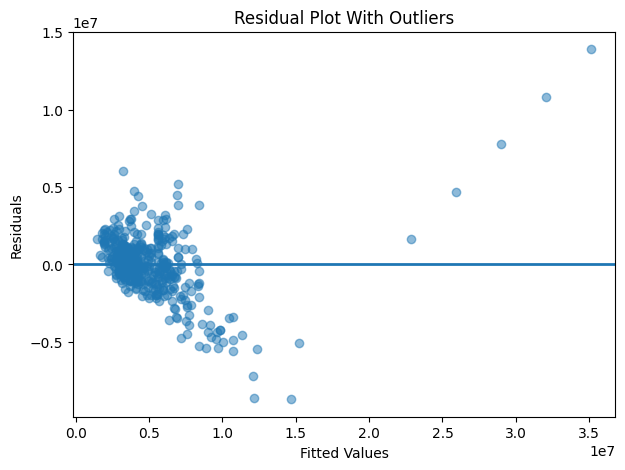

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("Housing.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:\n", df.head())

data = df[["area", "price"]].dropna()
X = data[["area"]]
y = data["price"]

print("\nPredictor: area")
print("Target: price")

plt.figure(figsize=(7, 5))
plt.scatter(X, y, alpha=0.5)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

slope = model.coef_[0]
intercept = model.intercept_

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nOriginal Model")
print("Slope:", slope)
print("Intercept:", intercept)
print(f"Equation: price = {intercept:.2f} + {slope:.2f} * area")

print("\nModel Performance")
print(f"Training MSE: {train_mse:.2f}")
print(f"Testing MSE: {test_mse:.2f}")
print(f"Training RMSE: {train_rmse:.2f}")
print(f"Testing RMSE: {test_rmse:.2f}")
print(f"Training R² Score: {train_r2:.4f} ({train_r2 * 100:.2f}%)")
print(f"Testing R² Score: {test_r2:.4f} ({test_r2 * 100:.2f}%)")

idx = np.argsort(X_train["area"].values)

plt.figure(figsize=(7, 5))
plt.scatter(X_train["area"], y_train, alpha=0.5, label="Data")
plt.plot(
    X_train["area"].values[idx],
    y_train_pred[idx],
    linewidth=2,
    label="Regression Line"
)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Linear Regression")
plt.legend()
plt.show()

residuals = y_train - y_train_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_train_pred, residuals, alpha=0.5)
plt.axhline(0, linewidth=2)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

max_area = X_train["area"].max()
max_price = y_train.max()

outlier_X = pd.DataFrame({
    "area": max_area * np.array([1.5, 1.7, 1.9, 2.1, 2.3])
})

outlier_y = pd.Series(
    max_price * np.array([2, 2.5, 3, 3.5, 4])
)

X_out = pd.concat(
    [X_train.reset_index(drop=True), outlier_X],
    ignore_index=True
)

y_out = pd.concat(
    [y_train.reset_index(drop=True), outlier_y],
    ignore_index=True
)

model_out = LinearRegression()
model_out.fit(X_out, y_out)

out_slope = model_out.coef_[0]
out_intercept = model_out.intercept_

out_test_pred = model_out.predict(X_test)

out_test_mse = mean_squared_error(y_test, out_test_pred)
out_test_rmse = np.sqrt(out_test_mse)
out_test_r2 = r2_score(y_test, out_test_pred)

print("\nModel With Outliers")
print("Slope:", out_slope)
print("Intercept:", out_intercept)
print(f"Equation: price = {out_intercept:.2f} + {out_slope:.2f} * area")

print("\nPerformance With Outliers")
print(f"Testing MSE: {out_test_mse:.2f}")
print(f"Testing RMSE: {out_test_rmse:.2f}")
print(f"Testing R² Score: {out_test_r2:.4f} ({out_test_r2 * 100:.2f}%)")

print("\nParameter Comparison")
print(pd.DataFrame({
    "Parameter": ["Slope", "Intercept"],
    "Original": [slope, intercept],
    "With Outliers": [out_slope, out_intercept]
}).to_string(index=False))

print("\nR² Score Comparison")
print(f"Original Model : {test_r2 * 100:.2f}%")
print(f"With Outliers : {out_test_r2 * 100:.2f}%")

x_line = pd.DataFrame({
    "area": np.linspace(
        X_out["area"].min(),
        X_out["area"].max(),
        200
    )
})

plt.figure(figsize=(8, 5))
plt.scatter(X_train["area"], y_train, alpha=0.5, label="Original Data")
plt.scatter(
    outlier_X["area"],
    outlier_y,
    marker="x",
    s=80,
    label="Outliers"
)
plt.plot(
    x_line["area"],
    model.predict(x_line),
    linewidth=2,
    label="Original Line"
)
plt.plot(
    x_line["area"],
    model_out.predict(x_line),
    "--",
    linewidth=2,
    label="With Outliers"
)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Effect of Outliers on Regression")
plt.legend()
plt.show()

out_pred = model_out.predict(X_out)
out_residuals = y_out - out_pred

plt.figure(figsize=(7, 5))
plt.scatter(out_pred, out_residuals, alpha=0.5)
plt.axhline(0, linewidth=2)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot With Outliers")
plt.show()